In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

import warnings 
warnings.filterwarnings("ignore")

In [2]:
# Load data
data = pd.read_csv("logistic_data.csv")
data

,age,tenure_months,monthly_charges,support_calls,contract_type,internet_service,churn
0,27,34,78.89,1,Two year,Fiber optic,0
1,59,66,113.50,3,One year,Fiber optic,0
2,50,13,118.57,3,Month-to-month,Fiber optic,1
3,47,21,130.01,8,Month-to-month,NaN,1
4,63,54,68.72,0,Month-to-month,NaN,0
...,...,...,...,...,...,...,...
1495,19,5,97.12,7,Month-to-month,Fiber optic,1
1496,66,42,71.13,2,Month-to-month,Fiber optic,0
1497,70,48,85.54,4,One year,DSL,1
1498,37,7,33.74,0,Month-to-month,DSL,0


In [3]:
data.shape

(1500, 7)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1500 non-null   int64  
 1   tenure_months     1500 non-null   int64  
 2   monthly_charges   1500 non-null   float64
 3   support_calls     1500 non-null   int64  
 4   contract_type     1500 non-null   object 
 5   internet_service  1287 non-null   object 
 6   churn             1500 non-null   int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 82.2+ KB


In [5]:
data.isnull().sum()

age                   0
tenure_months         0
monthly_charges       0
support_calls         0
contract_type         0
internet_service    213
churn                 0
dtype: int64

In [6]:
# In internet service we have null values so we fill the data
data['internet_service'].fillna(data['internet_service'].mode()[0],inplace=True)

In [7]:
data.isnull().sum()

age                 0
tenure_months       0
monthly_charges     0
support_calls       0
contract_type       0
internet_service    0
churn               0
dtype: int64

In [8]:
data

,age,tenure_months,monthly_charges,support_calls,contract_type,internet_service,churn
0,27,34,78.89,1,Two year,Fiber optic,0
1,59,66,113.50,3,One year,Fiber optic,0
2,50,13,118.57,3,Month-to-month,Fiber optic,1
3,47,21,130.01,8,Month-to-month,Fiber optic,1
4,63,54,68.72,0,Month-to-month,Fiber optic,0
...,...,...,...,...,...,...,...
1495,19,5,97.12,7,Month-to-month,Fiber optic,1
1496,66,42,71.13,2,Month-to-month,Fiber optic,0
1497,70,48,85.54,4,One year,DSL,1
1498,37,7,33.74,0,Month-to-month,DSL,0


In [12]:
#  f=data.corr() we use this but in this data we have string data that string data does not convert numeric so we use this
f = data.corr(numeric_only = True)

<Axes: >

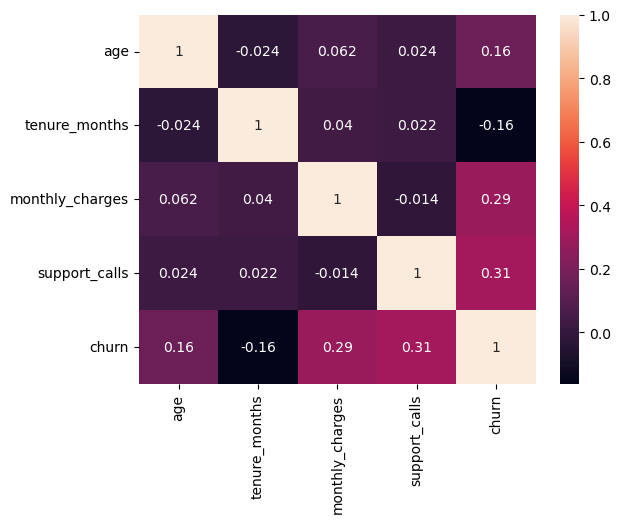

In [14]:
# visualize the data
sns.heatmap(f,annot = True)

In [16]:
data.describe()

,age,tenure_months,monthly_charges,support_calls,churn
count,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000
mean,44.214667,35.134000,86.039947,3.95600,0.342000
std,15.167574,20.809439,37.471247,2.57264,0.474538
min,18.000000,1.000000,20.120000,0.00000,0.000000
25%,31.000000,18.000000,53.895000,2.00000,0.000000
50%,45.000000,34.000000,87.145000,4.00000,0.000000
75%,57.000000,53.000000,116.910000,6.00000,1.000000
max,70.000000,72.000000,150.000000,8.00000,1.000000


In [17]:
data.head(1)

,age,tenure_months,monthly_charges,support_calls,contract_type,internet_service,churn
0,27,34,78.89,1,Two year,Fiber optic,0


In [24]:
x = data.drop("churn",axis = 1)
y = data["churn"]

# Month-to month its a text value.logistic regression want's numerical values so, we use pd.get_dummies() it convert text into numeric
x = pd.get_dummies(x,drop_first = True)

In [25]:
x

,age,tenure_months,monthly_charges,support_calls,contract_type_One year,contract_type_Two year,internet_service_Fiber optic
0,27,34,78.89,1,False,True,True
1,59,66,113.50,3,True,False,True
2,50,13,118.57,3,False,False,True
3,47,21,130.01,8,False,False,True
4,63,54,68.72,0,False,False,True
...,...,...,...,...,...,...,...
1495,19,5,97.12,7,False,False,True
1496,66,42,71.13,2,False,False,True
1497,70,48,85.54,4,True,False,False
1498,37,7,33.74,0,False,False,False


In [26]:
y

0       0
1       0
2       1
3       1
4       0
       ..
1495    1
1496    0
1497    1
1498    0
1499    0
Name: churn, Length: 1500, dtype: int64

In [27]:
# create train_test_split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [28]:
# Traing the model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [30]:
y_pred = model.predict(x_test)

In [36]:
# How goodness of model
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
print("Accuracy_score :- ",accuracy_score(y_test,y_pred))
print("Precision_score :- ",precision_score(y_test,y_pred))
print("Recall_score :- ",recall_score(y_test,y_pred))
print("F1_score :- ",f1_score(y_test,y_pred))

Accuracy_score :-  0.7933333333333333
Precision_score :-  0.7261904761904762
Recall_score :-  0.61
F1_score :-  0.6630434782608695


In [33]:
# It gives the loss of the model
from sklearn.metrics import log_loss
log_loss(y_test,y_pred)

7.4490217004175445

In [38]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[177,  23],
       [ 39,  61]])